# Smoothen Stock Price
Write a function named `smoothen_price`. Given the historical stock price data (represented by a 1D numpy array) and a window size (an integer) as inputs, the function smoothens the stock price using a moving average filter. You can use the simple moving average filter. The function should plot the original stock price and smoothened stock price. Make sure your plot is clearly labeled. Do not use the built-in moving average filters. 

Test your function using the opening price of Tesla from "TSLA.csv" and window size 100. Here is the expected output:
![TSLA](assets/output.png)


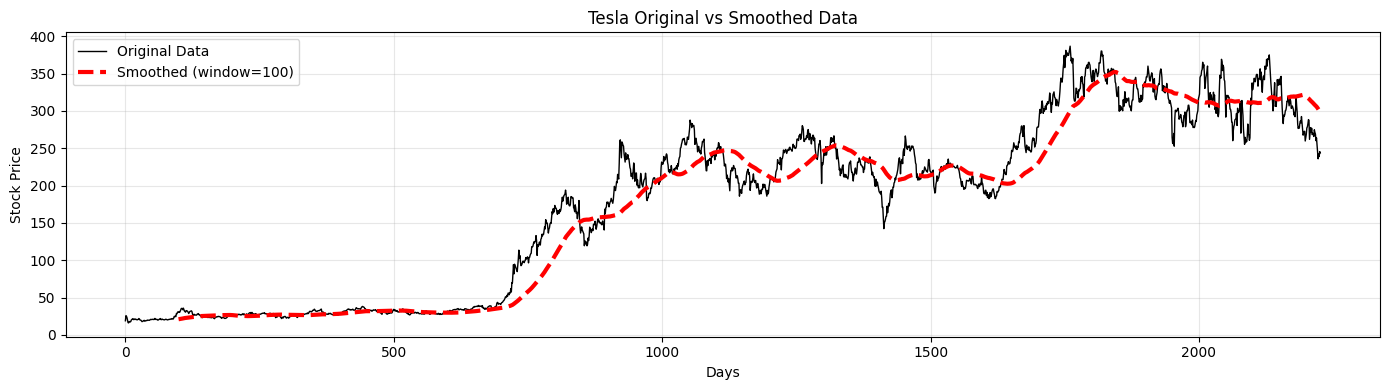

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def smoothen_price(prices: np.ndarray, window: int) -> np.ndarray:
    """
    Smoothen stock prices using a simple moving average (manual implementation)
    and plot both the original and smoothed prices.

    Parameters:

    prices : np.ndarray
        1D array of stock prices (e.g., daily opening prices).
    window : int
        Size of the moving window (number of days to average over).

    Returns:

    np.ndarray
        1D array of smoothed prices. The first (window - 1) entries are np.nan
        because there are not enough past values to form a full window.
    """
    n = len(prices)

    # Create an array filled with NaN for the smoothed result
    smoothed = np.full(n, np.nan)

    # Manually compute the simple moving average
    # For each index i starting from window-1, take the mean of the
    # previous `window` prices (including i itself)
    for i in range(window - 1, n):
        window_values = prices[i - window + 1 : i + 1]
        smoothed[i] = np.mean(window_values)

    # Prepare x-axis as "days" (0, 1, 2, ..., n-1)
    days = np.arange(n)

    # Create the plot
    plt.figure(figsize=(14, 4))
    # Original price in black
    plt.plot(days, prices, color="black", linewidth=1, label="Original Data")
    # Smoothed price in red dashed line
    plt.plot(
        days,
        smoothed,
        linestyle="--",
        color="red",
        linewidth=3,
        label=f"Smoothed (window={window})",
    )

    # Add title and axis labels
    plt.title("Tesla Original vs Smoothed Data")
    plt.xlabel("Days")
    plt.ylabel("Stock Price")

    # Add grid and legend for clarity
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return smoothed



# Example: test the function

# Load Tesla CSV (adjust the path if needed)
tsla_df = pd.read_csv(r"C:\Users\HP\Desktop\509_demo\assignment-7-pandas-Sienna-Zhang\assets\TSLA.csv")

# Use the opening price column; change "Open" if your column name is different
tsla_open = tsla_df["Open"].to_numpy()

# Smooth with window size 100 and plot
smoothed_tsla = smoothen_price(tsla_open, window=100)


# Linear Regression

Write a program to accomplish the following goals:

- Load the "penguins.csv" data. 
- Remove all rows containing empty fields. 
- Fit a linear model to predict how body mass (dependent variable) of penguins is correlated to flipper length (independent variable).
- Print out the mean squared error and $R^2$ value.
Choose the appropriate plot to compare the actual body mass and the predicted body mass. Clearly label your plot.

Mean Squared Error (MSE): 154546.19
R^2 score: 0.7590


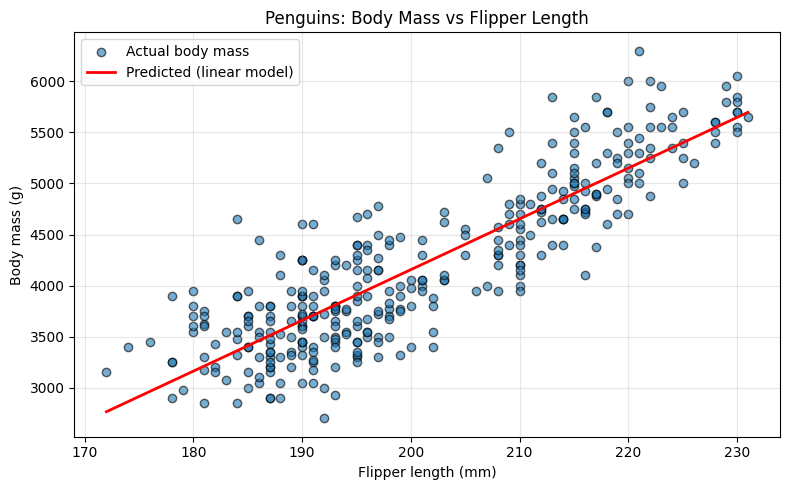

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# 1. Load the dataset
df = pd.read_csv(r"C:\Users\HP\Desktop\509_demo\assignment-7-pandas-Sienna-Zhang\assets\penguins.csv")   # change path if needed

# 2. Remove rows with any missing values
#    This ensures both flipper_length_mm and body_mass_g are complete.
df = df.dropna(subset=["flipper_length_mm", "body_mass_g"])

# 3. Prepare features (X) and target (y)
#    X must be 2D for scikit-learn: shape (n_samples, n_features)
X = df[["flipper_length_mm"]].to_numpy()   # independent variable
y = df["body_mass_g"].to_numpy()           # dependent variable

# 4. Fit a linear regression model
model = LinearRegression()
model.fit(X, y)

# 5. Make predictions on the same X
y_pred = model.predict(X)

# 6. Compute evaluation metrics: MSE and R^2
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 score: {r2:.4f}")

# 7. Plot actual vs predicted using a scatter + regression line

# Sort by X so the regression line is not jagged
order = np.argsort(X[:, 0])
X_sorted = X[order]
y_sorted = y[order]
y_pred_sorted = y_pred[order]

plt.figure(figsize=(8, 5))

# Scatter plot of actual data
plt.scatter(
    X_sorted,
    y_sorted,
    alpha=0.6,
    edgecolor="k",
    label="Actual body mass",
)

# Regression line (predicted values)
plt.plot(
    X_sorted,
    y_pred_sorted,
    color="red",
    linewidth=2,
    label="Predicted (linear model)",
)

plt.title("Penguins: Body Mass vs Flipper Length")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Logistic Regression

We have discussed linear regression in class. In this problem, you will explore logistic regression. Specifically, you will preprocess the dataset using pandas for logistic regression. Different from linear regression, logistic regression considers binary dependent variables rather than continuous dependent variables. Logistic regression is widely-used to predict binary outcomes based on a set of features (independent variables). 

Write a program to accomplish the following:

- Load the "diabetes.csv" file using pandas.
- Extract the following columns as your independent variables: Glucose, BloodPressure, and BMI. Extract the top 75% rows as the features in training dataset named feature_train. For practice purpose, **do not use** the built-in dataset splitting function in this problem. In your future projects, you can use `train_test_split` from `sklearn.model_selection` to automatically split the dataset for you. 
- Extract the "Outcome" column as the dependent variable. Extract the top 75% rows as the labels in the training dataset, named outcome_train.  For practice purpose, do not use the built-in dataset splitting function in this problem.
- Keep the rest of data as your testing dataset. Let's name the features in testing dataset as `feature_test`
- Instantiate a logistic regression model named `logreg`. Fit the model using your training dataset. You can use the following code snippet:
    ```py
    logreg = LogisticRegression()
    logreg.fit(feature_train, outcome_train)
    ```

- Let's evaluate the quality of prediction. Test the learned model using `outcome_pred = logreg.predict(feature_test)`
Compare `outcome_pred` with the actual outcome in testing dataset, count the percentage of positive patients that are correctly predicted by your model. For practice purpose, do not use the built-in report/summary or confusion matrix for calculation. 
- Print out the false negative and false positive of your model. For practice purpose, do not use the built-in report/summary or confusion matrix for calculation. 

In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Load dataset
df = pd.read_csv(r"C:\Users\HP\Desktop\509_demo\assignment-7-pandas-Sienna-Zhang\assets\diabetes.csv")   # change path if needed


# 2. Select independent variables (features)
features = df[["Glucose", "BloodPressure", "BMI"]]

# 3. Select dependent variable (labels)
outcome = df["Outcome"]


# 4. Manual train-test split (75% train, 25% test)
n = len(df)
split_index = int(0.75 * n)

feature_train = features.iloc[:split_index].to_numpy()
feature_test  = features.iloc[split_index:].to_numpy()

outcome_train = outcome.iloc[:split_index].to_numpy()
outcome_test  = outcome.iloc[split_index:].to_numpy()


# 5. Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(feature_train, outcome_train)


# 6. Make predictions
outcome_pred = logreg.predict(feature_test)


# 7. Manual evaluation
TP = 0   # true positive
FP = 0   # false positive
FN = 0   # false negative

for actual, pred in zip(outcome_test, outcome_pred):
    if actual == 1 and pred == 1:
        TP += 1
    elif actual == 0 and pred == 1:
        FP += 1
    elif actual == 1 and pred == 0:
        FN += 1

# Positive accuracy: TP / (TP + FN)
if TP + FN > 0:
    positive_accuracy = TP / (TP + FN)
else:
    positive_accuracy = 0


# 8. Print results
print("True Positive (TP):", TP)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print(f"Positive prediction accuracy: {positive_accuracy:.4f}")


True Positive (TP): 36
False Positive (FP): 11
False Negative (FN): 34
Positive prediction accuracy: 0.5143
